In [2]:
import sys 
print(sys.executable)

c:\Users\Pony\Desktop\MLS_AI\.venv\Scripts\python.exe


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
(16512, 8) (4128, 8) (16512,) (4128,)
Shape of normalized X_train: (16512, 8)


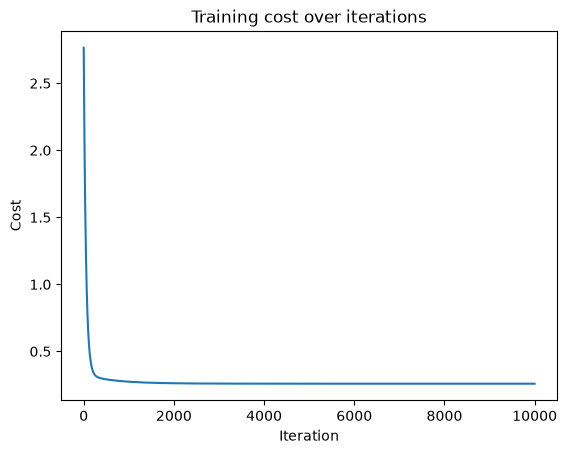

Train R²: 0.6125504311472598
Test R²: 0.5757056304556571


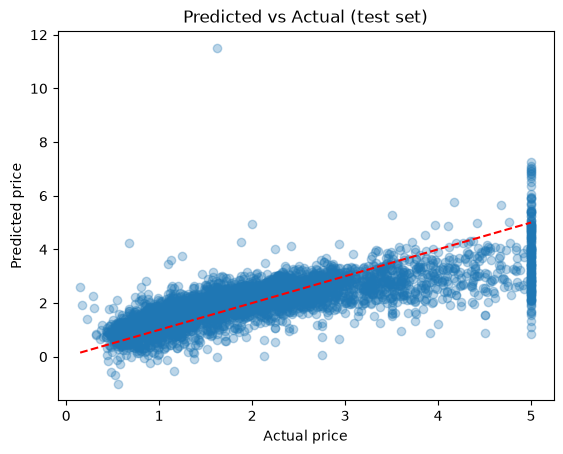

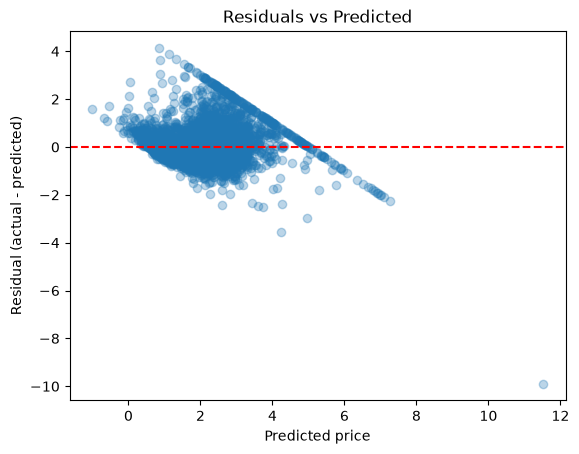

In [7]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

def normazlize(X):
    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma 

def predict(X, w, b):
    return np.dot(X,w) + b

def compute_cost(X, y, w, b):
    m = X.shape[0]
    y_hat = predict(X, w, b)
    cost = np.sum((y_hat - y) ** 2) / (2 * m)
    return cost

def compute_gradient(X, y, w, b):
    m = X.shape[0]
    y_hat = predict(X, w, b)
    error = y_hat - y
    dj_dw = (X.T @ error) / m
    dj_db = np.sum(error) / m
    return dj_dw, dj_db

def gradient_descent(X, y, w_init, b_init, alpha, num_iters):
    w, b = w_init.copy(), b_init
    cost_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost_history.append(compute_cost(X, y, w, b))
    return w, b, cost_history

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)



data = fetch_california_housing(as_frame = True)
df = data.frame

df.head()
df.info()
df.describe()

X = df.drop(columns = 'MedHouseVal')
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size = 0.2,    # 20% goes to test, 80% stays for training
    random_state=42     # fixes the randomness so we get the same split every time we run this   
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape) 

# normalizing the dataset 
X_train_norm, mu, sigma = normazlize(X_train.values)
X_test_norm = (X_test.values - mu ) / sigma 

print(f"Shape of normalized X_train: {X_train_norm.shape}") 

w = np.zeros(X_train_norm.shape[1])
b = 0.0
w, b, cost_history = gradient_descent(X_train_norm,y_train.values, w, b, alpha = 0.01, num_iters = 10000)

# plotting the cost 
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Training cost over iterations")
plt.show()

y_train_predictions = predict(X_train_norm, w, b)
y_test_predictions = predict(X_test_norm, w, b)


r2_train = r2_score(y_train.values, y_train_predictions)
r2_test = r2_score(y_test.values, y_test_predictions)

print("Train R²:", r2_train)
print("Test R²:", r2_test)

# Predicted vs Actual
plt.scatter(y_test.values, y_test_predictions, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Predicted vs Actual (test set)")
plt.show()

# Residuals
residuals = y_test.values - y_test_predictions
plt.scatter(y_test_predictions, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted price")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residuals vs Predicted")
plt.show()
